Francisco Benita, 2026

# This notebook creates hexagonal grids and centroids by passing the boundary of ech city

In [1]:
## Replace the urls by the gpkg files provided in Zenodo

boundaries_dict = {
"Jakarta": "https://www.dropbox.com/scl/fi/e407ghh550cve039dpg2w/Jakarta_boundary.gpkg?rlkey=a75ym7fbgh2v0bxs321zr6g7z&st=qgvxfn0s&dl=1",
"Manila": "https://www.dropbox.com/scl/fi/l08g71niyf49tag16ezda/Manila_boundary.gpkg?rlkey=yrsjkklyp2cf3x1t0jjswe7i7&st=11b7ughn&dl=1",
"Ho Chi Minh City": "https://www.dropbox.com/scl/fi/zeot0bz2cwznoaqre2e0f/Ho_Chi_Minh_City_boundary.gpkg?rlkey=pa9pd5omwvd02cqcluj8ivxza&st=73lf8tlu&dl=1",
"Phnom Penh": "https://www.dropbox.com/scl/fi/lu6b5r7gseg1dlxdvy6z6/Phnom_Penh_boundary.gpkg?rlkey=e9o9k04rjr1xebtduqlrsu7xj&st=8i5k701j&dl=1"
}
print(boundaries_dict)

{'Jakarta': 'https://www.dropbox.com/scl/fi/e407ghh550cve039dpg2w/Jakarta_boundary.gpkg?rlkey=a75ym7fbgh2v0bxs321zr6g7z&st=qgvxfn0s&dl=1', 'Manila': 'https://www.dropbox.com/scl/fi/l08g71niyf49tag16ezda/Manila_boundary.gpkg?rlkey=yrsjkklyp2cf3x1t0jjswe7i7&st=11b7ughn&dl=1', 'Ho Chi Minh City': 'https://www.dropbox.com/scl/fi/zeot0bz2cwznoaqre2e0f/Ho_Chi_Minh_City_boundary.gpkg?rlkey=pa9pd5omwvd02cqcluj8ivxza&st=73lf8tlu&dl=1', 'Phnom Penh': 'https://www.dropbox.com/scl/fi/lu6b5r7gseg1dlxdvy6z6/Phnom_Penh_boundary.gpkg?rlkey=e9o9k04rjr1xebtduqlrsu7xj&st=8i5k701j&dl=1'}


In [2]:
!pip install geopandas pyogc

/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:200: RuntimeWarning: File /vsicurl/https://www.dropbox.com/scl/fi/e407ghh550cve039dpg2w/Jakarta_boundary.gpkg?rlkey=a75ym7fbgh2v0bxs321zr6g7z&st=qgvxfn0s&dl=1 has GPKG application_id, but non conformant file extension
  return ogr_read(
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:200: RuntimeWarning: File /vsicurl/https://www.dropbox.com/scl/fi/l08g71niyf49tag16ezda/Manila_boundary.gpkg?rlkey=yrsjkklyp2cf3x1t0jjswe7i7&st=11b7ughn&dl=1 has GPKG application_id, but non conformant file extension
  return ogr_read(
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:200: RuntimeWarning: File /vsicurl/https://www.dropbox.com/scl/fi/zeot0bz2cwznoaqre2e0f/Ho_Chi_Minh_City_boundary.gpkg?rlkey=pa9pd5omwvd02cqcluj8ivxza&st=73lf8tlu&dl=1 has GPKG application_id, but non conformant file extension
  return ogr_read(
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:200: RuntimeWarning: File /vsicurl/https://www.dropbox.com/sc

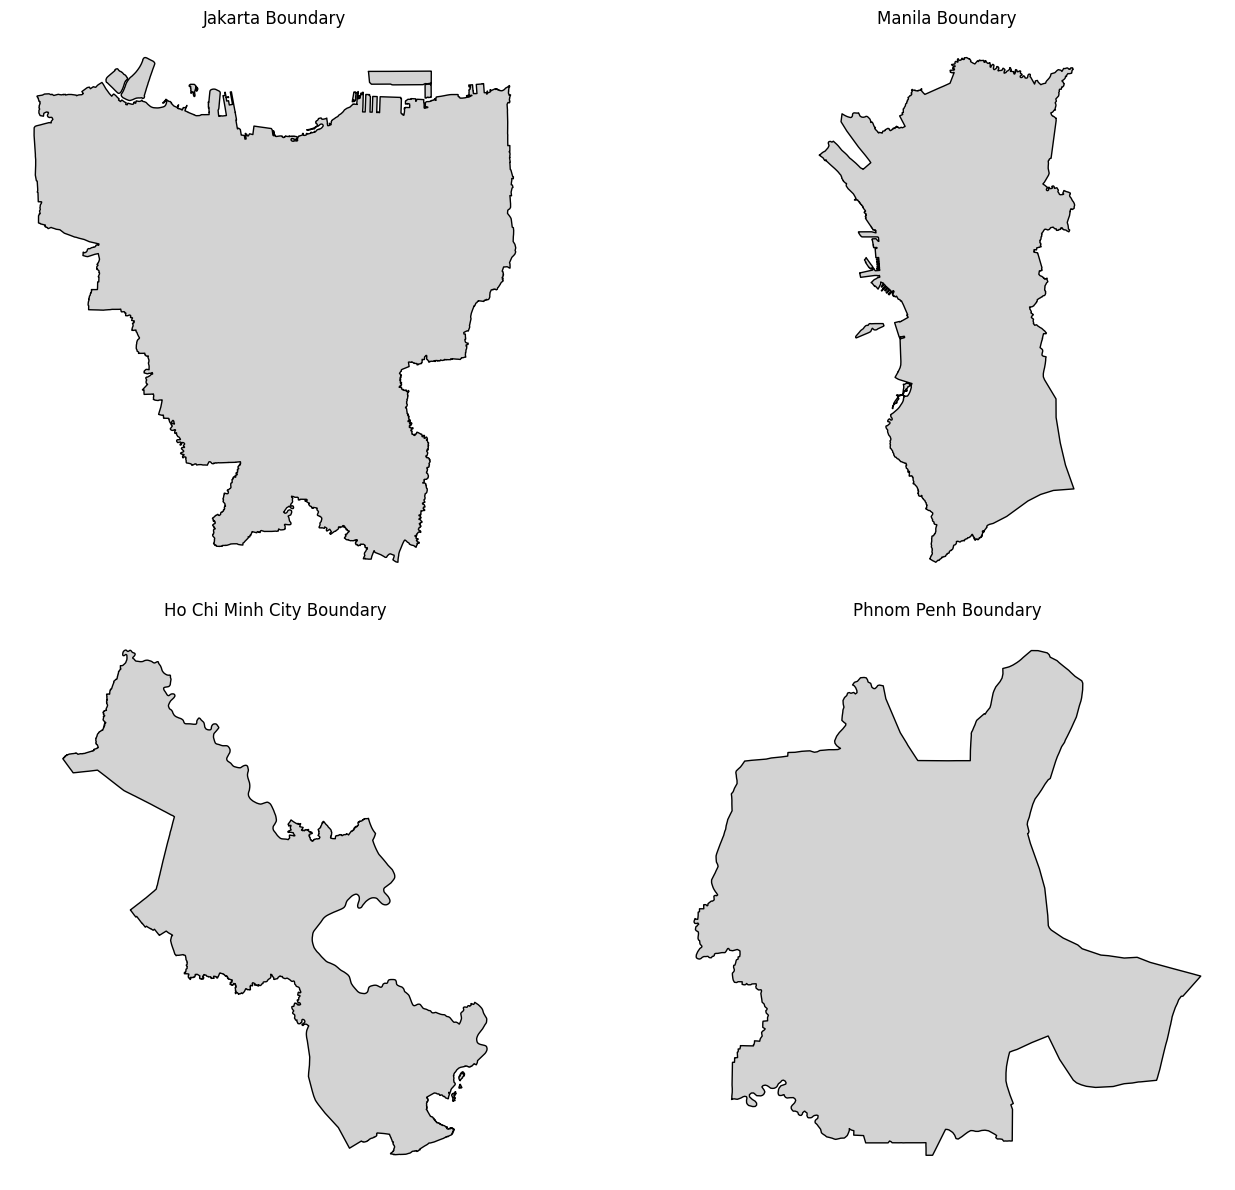

In [3]:
import matplotlib.pyplot as plt
import geopandas

# Create a figure to hold all plots
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 12))
axes = axes.flatten() # Flatten the 2x2 array of axes for easy iteration

for i, (city_name, url) in enumerate(boundaries_dict.items()):
    try:
        # Read the .gpkg file directly from the URL
        city_boundary = geopandas.read_file(url)

        # Plot the boundary on the current subplot axis
        city_boundary.plot(ax=axes[i], edgecolor='black', facecolor='lightgray')
        axes[i].set_title(f'{city_name} Boundary')
        axes[i].set_axis_off() # Turn off axes for cleaner map display
    except Exception as e:
        print(f"Error processing {city_name}: {e}")
        axes[i].set_title(f'Error loading {city_name}')
        axes[i].set_axis_off()

plt.tight_layout() # Adjust layout to prevent overlapping titles
plt.show()

## Generate Hexagonal Grids and Centroids

This section will process each city boundary to:
1.  **Reproject** the boundary to a local Universal Transverse Mercator (UTM) coordinate reference system for accurate spatial calculations.
2.  **Generate a hexagonal grid** using H3 at resolution 9, which provides hexagons with an approximate circumradius.
3.  **Clip** the generated hexagons to ensure they are within the city's geographical boundaries.
4.  **Extract the centroids** of these hexagonal cells.
5.  **Save** both the hexagonal grid and their centroids as separate `.gpkg` files for each city.

In [4]:
import geopandas as gpd
import pandas as pd
import numpy as np
import math
import os
from shapely.geometry import Polygon

# Parameters
radii = [400, 800, 1200]  # 5, 10, 15 min walks
output_dir = 'city_hex_grids'
os.makedirs(output_dir, exist_ok=True)

for boundary_name, url in boundaries_dict.items():
    print(f"\nProcessing boundary: {boundary_name}")

    try:
        # 1. Download and read boundary
        gdf = gpd.read_file(url)
        if len(gdf) > 1:
            gdf = gdf.dissolve()

        # 2. Automatically estimate local UTM CRS
        target_crs = gdf.estimate_utm_crs()
        gdf_projected = gdf.to_crs(target_crs)
        print(f"  Projected to: {target_crs}")

        for radius in radii:
            print(f"  Generating grid for radius: {radius}m...")

            # 3. Setup grid parameters
            buffer_distance = radius
            buffered_boundary = gdf_projected.buffer(buffer_distance)
            bounds = buffered_boundary.bounds

            xmin, ymin, xmax, ymax = bounds.minx.iloc[0], bounds.miny.iloc[0], bounds.maxx.iloc[0], bounds.maxy.iloc[0]

            step_size = radius * math.sqrt(3)
            x_step = radius * 3 / 2

            # 4. Generate points
            x_coords = np.arange(xmin - radius, xmax + radius, x_step)
            points = []
            for i, x in enumerate(x_coords):
                y_offset = step_size / 2 if i % 2 != 0 else 0
                y_coords = np.arange(ymin - radius + y_offset, ymax + radius + step_size, step_size)
                for y in y_coords:
                    points.append((x, y))

            # 5. Create hexagons
            hexagons = [Polygon([(px + radius * math.cos(math.pi / 180 * (60 * j)),
                                 py + radius * math.sin(math.pi / 180 * (60 * j)))
                                for j in range(6)]) for px, py in points]

            # 6. Build Grid and Intersect
            grid = gpd.GeoDataFrame(geometry=hexagons, crs=target_crs)
            grid_reprojected = grid.to_crs(gdf.crs)

            # Intersection in original CRS
            intersection = gpd.overlay(gdf, grid_reprojected, how='intersection')
            intersection_projected = intersection.to_crs(target_crs)
            intersection_projected['area'] = intersection_projected.geometry.area

            # 7. Filter for full hexagons
            full_hexagon_area = (3 * math.sqrt(3) / 2) * (radius**2)
            tolerance = full_hexagon_area * 0.05

            polished_intersection = intersection_projected[
                (intersection_projected['area'] >= full_hexagon_area - tolerance)
            ].copy()

            # 8. Create Centroids
            centroids_gdf = polished_intersection.copy()
            centroids_gdf['geometry'] = centroids_gdf.geometry.centroid

            # Reproject to WGS84
            final_grid = polished_intersection.to_crs(epsg=4326)
            final_centroids = centroids_gdf.to_crs(epsg=4326)

            # 9. Save Files
            city_slug = boundary_name.replace(" ", "_")
            grid_path = os.path.join(output_dir, f"{city_slug}_{radius}m_hex_grid.gpkg")
            centroids_path = os.path.join(output_dir, f"{city_slug}_{radius}m_centroids.gpkg")

            final_grid.to_file(grid_path, driver="GPKG")
            final_centroids.to_file(centroids_path, driver="GPKG")

            print(f"    Done: {len(final_grid)} hexagons at {radius}m.")

    except Exception as e:
        print(f"  Error processing {boundary_name}: {e}")

print(f"\nAll processing complete. Files are in '{output_dir}'.")


Processing boundary: Jakarta


/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:200: RuntimeWarning: File /vsicurl/https://www.dropbox.com/scl/fi/e407ghh550cve039dpg2w/Jakarta_boundary.gpkg?rlkey=a75ym7fbgh2v0bxs321zr6g7z&st=qgvxfn0s&dl=1 has GPKG application_id, but non conformant file extension
  return ogr_read(


  Projected to: EPSG:32748
  Generating grid for radius: 400m...
    Done: 1459 hexagons at 400m.
  Generating grid for radius: 800m...
    Done: 340 hexagons at 800m.
  Generating grid for radius: 1200m...
    Done: 143 hexagons at 1200m.

Processing boundary: Manila


/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:200: RuntimeWarning: File /vsicurl/https://www.dropbox.com/scl/fi/l08g71niyf49tag16ezda/Manila_boundary.gpkg?rlkey=yrsjkklyp2cf3x1t0jjswe7i7&st=11b7ughn&dl=1 has GPKG application_id, but non conformant file extension
  return ogr_read(


  Projected to: EPSG:32651
  Generating grid for radius: 400m...
    Done: 1530 hexagons at 400m.
  Generating grid for radius: 800m...
    Done: 358 hexagons at 800m.
  Generating grid for radius: 1200m...
    Done: 145 hexagons at 1200m.

Processing boundary: Ho Chi Minh City


/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:200: RuntimeWarning: File /vsicurl/https://www.dropbox.com/scl/fi/zeot0bz2cwznoaqre2e0f/Ho_Chi_Minh_City_boundary.gpkg?rlkey=pa9pd5omwvd02cqcluj8ivxza&st=73lf8tlu&dl=1 has GPKG application_id, but non conformant file extension
  return ogr_read(


  Projected to: EPSG:32648
  Generating grid for radius: 400m...
    Done: 4612 hexagons at 400m.
  Generating grid for radius: 800m...
    Done: 1094 hexagons at 800m.
  Generating grid for radius: 1200m...
    Done: 458 hexagons at 1200m.

Processing boundary: Phnom Penh


/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:200: RuntimeWarning: File /vsicurl/https://www.dropbox.com/scl/fi/lu6b5r7gseg1dlxdvy6z6/Phnom_Penh_boundary.gpkg?rlkey=e9o9k04rjr1xebtduqlrsu7xj&st=8i5k701j&dl=1 has GPKG application_id, but non conformant file extension
  return ogr_read(


  Projected to: EPSG:32648
  Generating grid for radius: 400m...
    Done: 1519 hexagons at 400m.
  Generating grid for radius: 800m...
    Done: 353 hexagons at 800m.
  Generating grid for radius: 1200m...
    Done: 146 hexagons at 1200m.

All processing complete. Files are in 'city_hex_grids'.


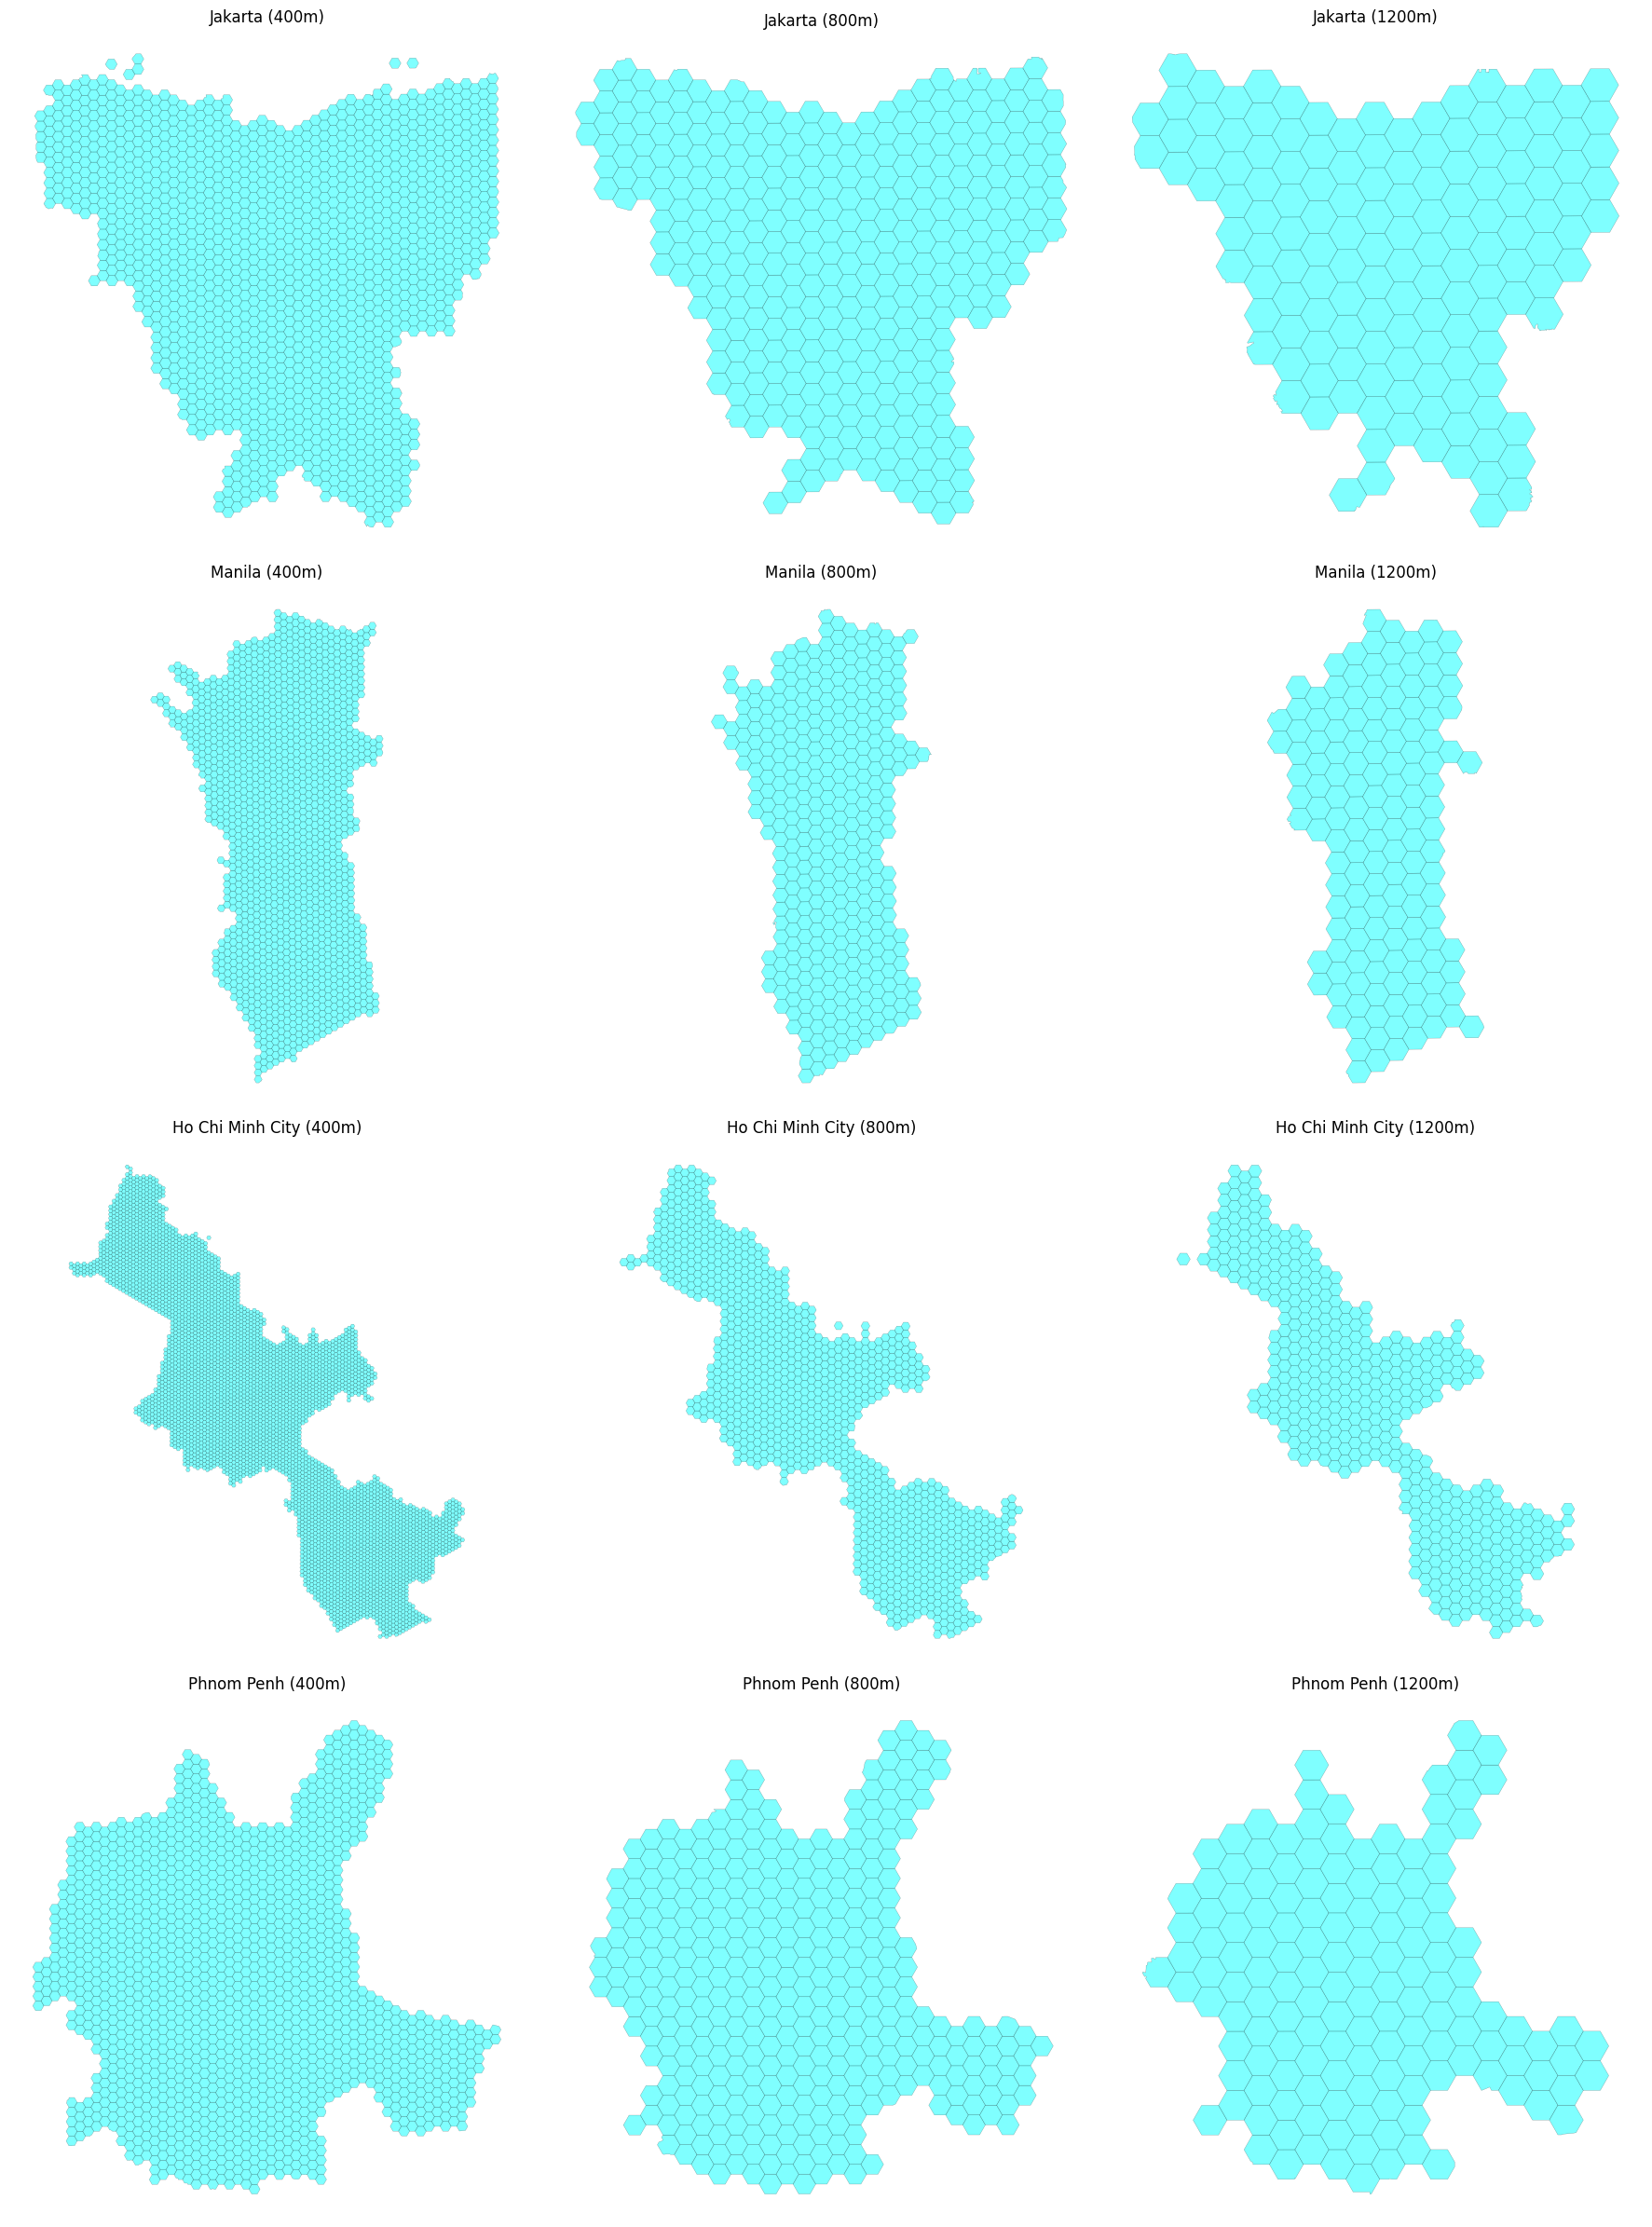

In [5]:
# Configuration
city_names = ["Jakarta", "Manila", "Ho Chi Minh City", "Phnom Penh"]
radii = [400, 800, 1200]
output_dir = 'city_hex_grids'

# Create a 4x3 grid of subplots
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(18, 24))

for i, city in enumerate(city_names):
    city_slug = city.replace(" ", "_")
    for j, radius in enumerate(radii):
        ax = axes[i, j]
        grid_path = os.path.join(output_dir, f"{city_slug}_{radius}m_hex_grid.gpkg")

        if os.path.exists(grid_path):
            try:
                grid = gpd.read_file(grid_path)
                grid.plot(ax=ax, edgecolor='black', facecolor='cyan', alpha=0.5, linewidth=0.2)
                ax.set_title(f"{city} ({radius}m)")
            except Exception as e:
                ax.set_title(f"Error: {city} {radius}m")
        else:
            ax.set_title(f"File Not Found: {city} {radius}m")

        ax.set_axis_off()

plt.tight_layout()
plt.show()

In [6]:
!pip freeze > colab_environment_snapshot.txt